# GNSS I Lab: From Satellite Signals to Position

> **Colab note:** This notebook is designed to run on **Google Colab**. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS166/blob/main/notebooks/01_gnss_positioning.ipynb)

## Introduction

GNSS receivers do not observe position directly. They receive modulated radio signals, identify the transmitting satellites, measure signal arrival times, and combine several apparent ranges to estimate position.

In this lab, you will follow that measurement chain using simplified signals and simulated pseudoranges.

The workflow is:

$$
\text{construct a signal}
\rightarrow
\text{identify the satellite}
\rightarrow
\text{measure a pseudorange}
\rightarrow
\text{solve for position}
$$

This is a conceptual lab. The signals and satellite observations are simplified so that the measurement process is visible and can be completed in one class period.

## Learning objectives

By the end of this lab, you should be able to:

- describe how a PRN code and navigation data modulate a carrier wave
- explain how correlation identifies a satellite and measures code arrival time
- convert a code-time offset into an apparent range
- explain why receiver position and clock bias must be solved together
- evaluate how satellite geometry affects position uncertainty

## Notebook Outline:
- [Part I: Build a GPS-like Signal](#part-i-build-a-gps-like-signal)
- [Part II: Identify a satellite by correlation](#part-ii-identify-a-satellite-by-correlation)
- [Part III: Remove the PRN Modulation](#part-iii-remove-the-prn-modulation)
- [Part IV: From Code Timing to Pseudorange](#part-iv-from-code-timing-to-pseudorange)
- [Part V: Investigate Satellite Geometry](#part-v-investigate-satellite-geometry)
- [Part VI: Optional extension: Why code does not identify one carrier cycle](#part-vi-optional-extension-why-code-does-not-identify-one-carrier-cycle)
- [Synthesis](#Synthesis)
- [Summary](#Summary)

## Setup

This notebook requires only NumPy and Matplotlib, both of which are already available in Google Colab.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Physical constants
c = 299_792_458.0       # speed of light (m/s)
f_L1 = 1_575.42e6       # GPS L1 frequency (Hz)
lambda_L1 = c / f_L1    # L1 wavelength (m)

print(f"L1 wavelength: {lambda_L1 * 100:.2f} cm")

L1 wavelength: 19.03 cm


---

## Part I: Build a GPS-like signal

A simplified GPS signal can be represented as

$$
s(t)=C(t)D(t)\cos(2\pi f_ct),
$$

where:

- $\cos(2\pi f_ct)$ is the carrier
- $C(t)$ is the satellite's PRN code, represented by $+1$ and $-1$
- $D(t)$ is the navigation data, also represented by $+1$ and $-1$

Multiplication by $-1$ reverses the carrier phase by $180^\circ$. This is binary phase-shift keying.

**Important:** The frequencies below are scaled for visualization. On the real L1 signal, approximately 1,540 carrier cycles occur during one C/A-code chip.

### Prediction 

Before running the next cell, predict what will happen to the carrier whenever the PRN code changes from $+1$ to $-1$. Record your prediction before continuing.

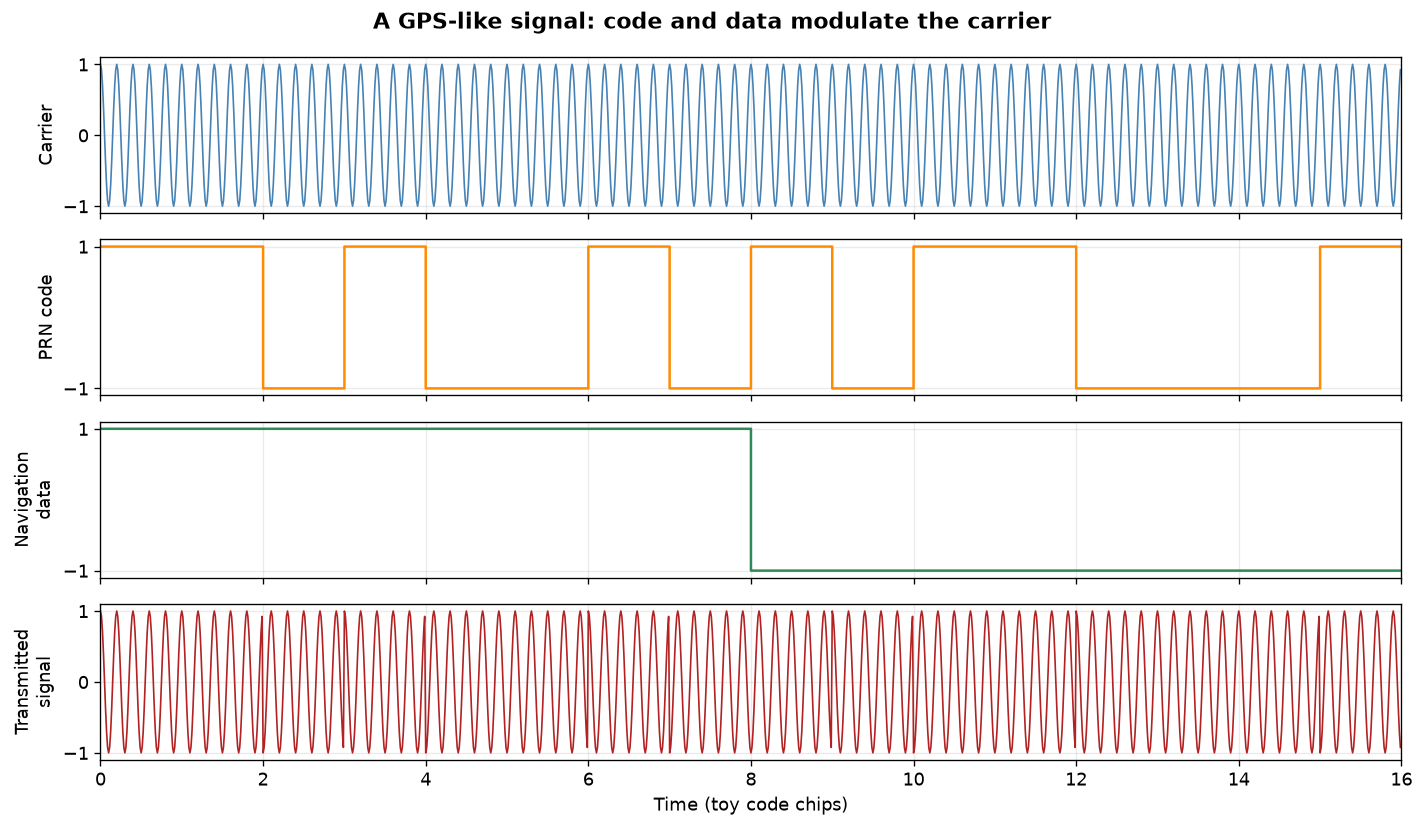

In [2]:
# A short toy PRN code. Real GPS C/A codes contain 1,023 chips.
prn_chips = np.array([1, 1, -1, 1, -1, -1, 1, -1,
                      1, -1, 1, 1, -1, -1, -1, 1])

samples_per_chip = 80
carrier_cycles_per_chip = 5

# Expand each chip so that it can be plotted as a continuous signal.
prn = np.repeat(prn_chips, samples_per_chip)

# Navigation data change much more slowly than the PRN code.
# Two toy data bits are shown here; the real timing ratio is much larger.
navigation_bits = np.array([1, -1])
navigation_data = np.repeat(
    navigation_bits,
    len(prn) // len(navigation_bits),
)

t = np.arange(len(prn)) / samples_per_chip
carrier = np.cos(2 * np.pi * carrier_cycles_per_chip * t)

# The PRN code and navigation data modulate the carrier.
modulation = prn * navigation_data
transmitted_signal = carrier * modulation

fig, axes = plt.subplots(4, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, carrier, color="steelblue", lw=1)
axes[0].set_ylabel("Carrier")

axes[1].step(t, prn, where="post", color="darkorange")
axes[1].set_ylabel("PRN code")
axes[1].set_yticks([-1, 1])

axes[2].step(t, navigation_data, where="post", color="seagreen")
axes[2].set_ylabel("Navigation\ndata")
axes[2].set_yticks([-1, 1])

axes[3].plot(t, transmitted_signal, color="firebrick", lw=1)
axes[3].set_ylabel("Transmitted\nsignal")
axes[3].set_xlabel("Time (toy code chips)")

for ax in axes:
    ax.set_xlim(0, len(prn_chips))

fig.suptitle("A GPS-like signal: code and data modulate the carrier", fontweight="bold")
plt.tight_layout()
plt.show()

> **Interpret the signal:** 
> 1. Does modulation change the carrier frequency?
> 2. What happens to the carrier phase when the modulation changes sign?
> 3. Which component identifies the transmitting satellite?

---

## Part II: Identify a satellite by correlation

A receiver stores or generates the known PRN code for every satellite it may observe. It shifts each candidate code through possible arrival times and compares it with the received signal.

The correct PRN code produces a strong correlation peak when its timing aligns with the received code.

For clarity, the next simulation starts after the receiver has mixed the radio-frequency signal down to baseband. It therefore shows the code-acquisition step rather than the high-frequency carrier search.

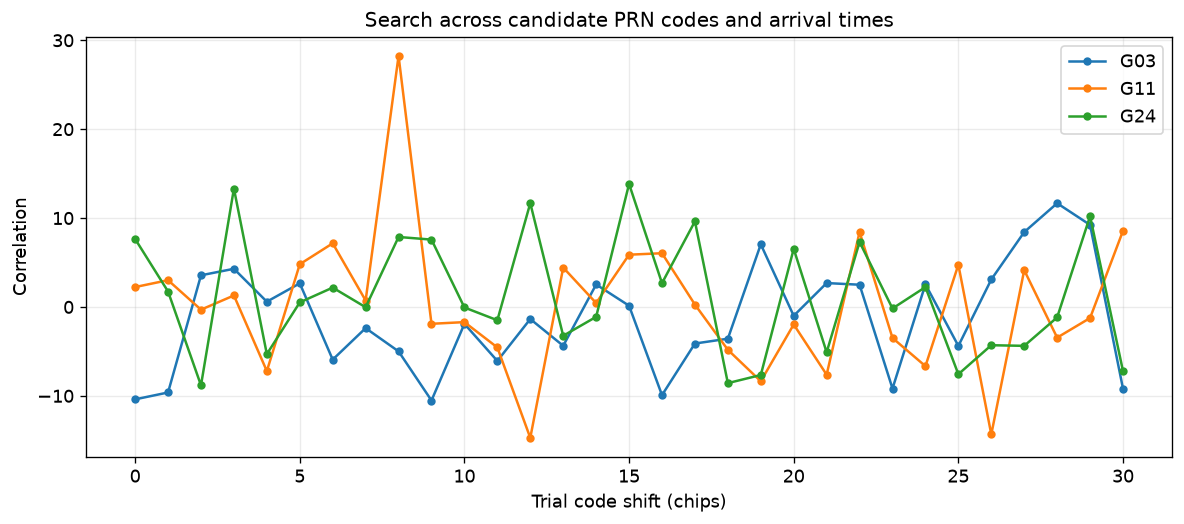

Identified satellite: G11
Measured code shift:  8 chips


In [3]:
def make_toy_prn(seed, n_chips=31):
    # Return a reproducible toy +1/-1 code.
    rng = np.random.default_rng(seed)
    return rng.choice([-1, 1], size=n_chips)


def circular_correlation(received, candidate):
    # Correlate a received periodic code with every circular shift.
    return np.array([
        np.sum(received * np.roll(candidate, shift))
        for shift in range(len(candidate))
    ])


candidate_codes = {
    "G03": make_toy_prn(3),
    "G11": make_toy_prn(11),
    "G24": make_toy_prn(24),
}

# The simulated receiver does not initially know these two values.
transmitting_satellite = "G11"
true_code_shift = 8

rng = np.random.default_rng(166)
received_code = np.roll(
    candidate_codes[transmitting_satellite], true_code_shift
) + rng.normal(0, 0.55, 31)

correlations = {
    satellite: circular_correlation(received_code, candidate)
    for satellite, candidate in candidate_codes.items()
}

fig, ax = plt.subplots(figsize=(10, 4.5))
for satellite, values in correlations.items():
    ax.plot(range(len(values)), values, "o-", ms=4, label=satellite)

ax.set_xlabel("Trial code shift (chips)")
ax.set_ylabel("Correlation")
ax.set_title("Search across candidate PRN codes and arrival times")
ax.legend()
plt.tight_layout()
plt.show()

best_satellite = max(
    correlations,
    key=lambda satellite: np.max(correlations[satellite]),
)
measured_shift = int(np.argmax(correlations[best_satellite]))

print(f"Identified satellite: {best_satellite}")
print(f"Measured code shift:  {measured_shift} chips")

> **Interpret the correlation:**
> 1. Which satellite was identified?
> 2. At what code shift does its correlation peak occur?
> 3. Why do the other candidate codes not produce equally strong peaks?
> 4. Increase the noise standard deviation from `0.55` to `2.0`. Can the receiver still identify the satellite and code shift?

Restore the original noise level before continuing.

---

## Part III: Remove the PRN modulation

After acquisition, the receiver aligns its locally generated PRN code with the received signal. Multiplying by this aligned $+1/-1$ code removes the deliberate PRN phase reversals because

$$
C(t)C(t)=C(t)^2=1.
$$

The demonstration below uses a constant navigation-data bit so that the effect of removing the PRN code is easy to see.

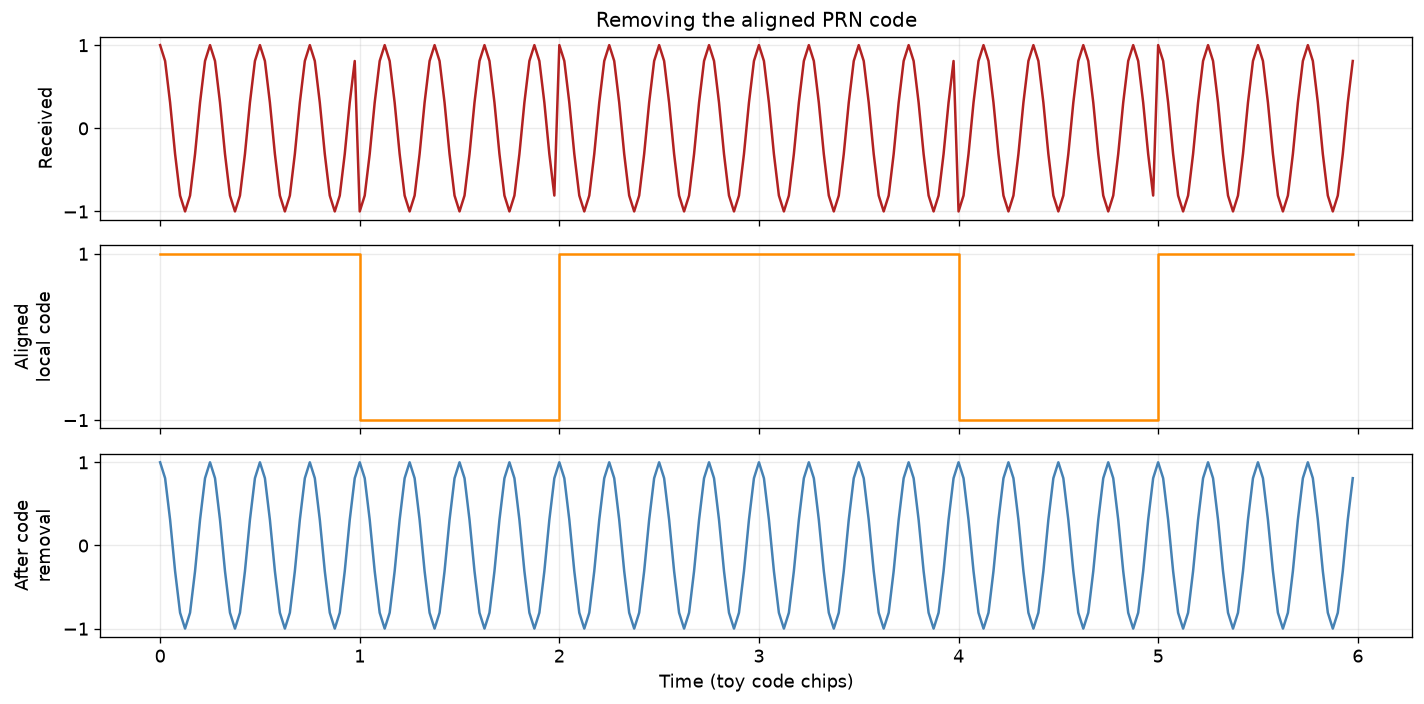

In [4]:
# Construct a short passband signal from the identified satellite.
acq_chips = candidate_codes[transmitting_satellite]
acq_samples_per_chip = 40
acq_cycles_per_chip = 4

local_code = np.repeat(acq_chips, acq_samples_per_chip)
t_acq = np.arange(len(local_code)) / acq_samples_per_chip
local_carrier = np.cos(2 * np.pi * acq_cycles_per_chip * t_acq)

sample_shift = true_code_shift * acq_samples_per_chip
received_passband = np.roll(local_carrier * local_code, sample_shift)

# Align the locally generated code using the measured correlation shift.
aligned_code = np.roll(
    np.repeat(candidate_codes[best_satellite], acq_samples_per_chip),
    measured_shift * acq_samples_per_chip,
)
code_wiped_signal = received_passband * aligned_code

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
plot_end = 6 * acq_samples_per_chip

axes[0].plot(t_acq[:plot_end], received_passband[:plot_end], color="firebrick")
axes[0].set_ylabel("Received")
axes[0].set_title("Removing the aligned PRN code")

axes[1].step(t_acq[:plot_end], aligned_code[:plot_end], where="post", color="darkorange")
axes[1].set_ylabel("Aligned\nlocal code")
axes[1].set_yticks([-1, 1])

axes[2].plot(t_acq[:plot_end], code_wiped_signal[:plot_end], color="steelblue")
axes[2].set_ylabel("After code\nremoval")
axes[2].set_xlabel("Time (toy code chips)")

plt.tight_layout()
plt.show()

### Test the alignment

Change the alignment below from `0` to `1`, run the cell, and compare the result with the recovered carrier above.

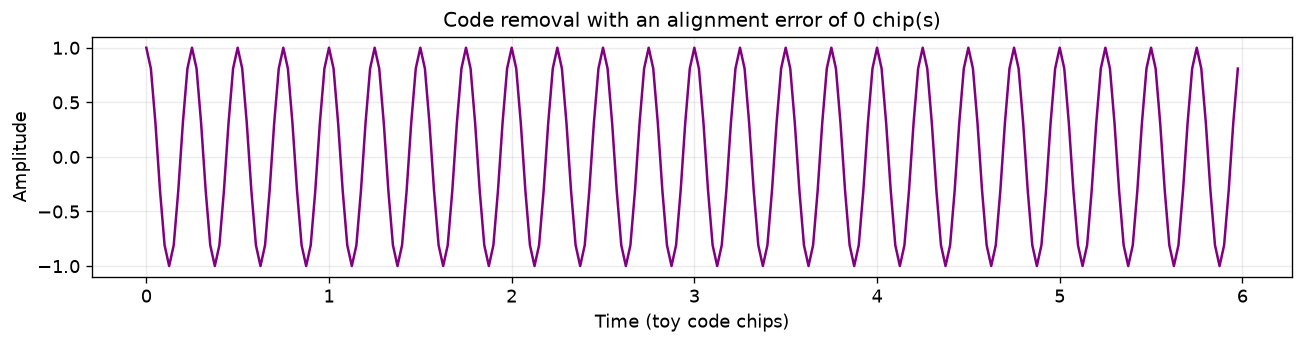

In [5]:
alignment_error_chips = 0  # Change to 1, then return it to 0.

test_aligned_code = np.roll(aligned_code, alignment_error_chips * acq_samples_per_chip)
test_wiped_signal = received_passband * test_aligned_code

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t_acq[:plot_end], test_wiped_signal[:plot_end], color="purple")
ax.set_xlabel("Time (toy code chips)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Code removal with an alignment error of {alignment_error_chips} chip(s)")
plt.tight_layout()
plt.show()

> **Interpret code removal:**
> 1. What does multiplication by the correctly aligned PRN code do?
> 2. Why does an incorrectly aligned code fail to recover a clean carrier?

Record brief answers before continuing.

---

## Part IV: From code timing to pseudorange

The real GPS C/A code is transmitted at 1.023 million chips per second. Calculate the duration and distance represented by one chip.

In [6]:
ca_chip_rate = 1.023e6  # chips/s

chip_duration = 1 / ca_chip_rate
chip_length = c * chip_duration
one_percent_chip = 0.01 * chip_length

print(f"Duration of one C/A-code chip: {chip_duration * 1e6:.3f} microseconds")
print(f"Distance represented by one chip: {chip_length:.1f} m")
print(f"One percent of a chip:             {one_percent_chip:.1f} m")

Duration of one C/A-code chip: 0.978 microseconds
Distance represented by one chip: 293.1 m
One percent of a chip:             2.9 m


The code pattern tells the receiver where it is within the repeating code sequence. Navigation data and approximate receiver time provide the additional timing context needed to form the full signal travel time.

The measured range is a **pseudorange** because receiver-clock bias and other effects are included:

$$
P_i=\rho_i+c\delta t_r+\epsilon_i,
$$

where this lab combines satellite-clock, atmospheric, multipath, and measurement effects into $\epsilon_i$.

> **Interpret the scale:**
> 1. Why does a 293 m chip length not limit code ranging to 293 m precision?
> 2. If the correlation peak can be measured to approximately 1% of a chip, what is the corresponding range precision?

---

## Part V: Solve for receiver position and clock bias

Each satellite supplies one pseudorange equation. The receiver has four basic unknowns:

- three position coordinates: $x$, $y$, and $z$
- receiver-clock bias: $c\delta t_r$

At least four satellites are therefore required. With more than four satellites, the position can be estimated using least squares.

The functions in the next cell implement the coordinate transformations and iterative position solver. Run the cell; you do not need to modify it.

In [7]:
def geodetic_to_ecef(latitude_deg, longitude_deg, height_m):
    # Convert WGS84 latitude, longitude, and height to ECEF coordinates.
    a = 6_378_137.0
    e2 = 6.69437999014e-3
    lat = np.deg2rad(latitude_deg)
    lon = np.deg2rad(longitude_deg)
    N = a / np.sqrt(1 - e2 * np.sin(lat) ** 2)
    x = (N + height_m) * np.cos(lat) * np.cos(lon)
    y = (N + height_m) * np.cos(lat) * np.sin(lon)
    z = (N * (1 - e2) + height_m) * np.sin(lat)
    return np.array([x, y, z])


def enu_los_to_ecef(azimuth_deg, elevation_deg, latitude_deg, longitude_deg):
    # Convert local azimuth/elevation unit vectors to ECEF unit vectors.
    az = np.deg2rad(np.asarray(azimuth_deg))
    el = np.deg2rad(np.asarray(elevation_deg))
    lat = np.deg2rad(latitude_deg)
    lon = np.deg2rad(longitude_deg)

    east = np.cos(el) * np.sin(az)
    north = np.cos(el) * np.cos(az)
    up = np.sin(el)

    x = -np.sin(lon) * east - np.sin(lat) * np.cos(lon) * north + np.cos(lat) * np.cos(lon) * up
    y =  np.cos(lon) * east - np.sin(lat) * np.sin(lon) * north + np.cos(lat) * np.sin(lon) * up
    z =  np.cos(lat) * north + np.sin(lat) * up
    return np.column_stack([x, y, z])


def satellites_from_sky(azimuth_deg, elevation_deg, receiver_xyz,
                        latitude_deg, longitude_deg, orbital_radius=26_560_000.0):
    # Place satellites on the GPS orbital-radius sphere along local sight lines.
    los = enu_los_to_ecef(
        azimuth_deg, elevation_deg, latitude_deg, longitude_deg
    )
    rdotu = los @ receiver_xyz
    r2 = receiver_xyz @ receiver_xyz
    distance = -rdotu + np.sqrt(rdotu**2 + orbital_radius**2 - r2)
    return receiver_xyz + distance[:, None] * los


def design_matrix(satellite_xyz, receiver_xyz):
    # Construct the linearized geometry matrix; clock bias is in meters.
    delta = satellite_xyz - receiver_xyz
    ranges = np.linalg.norm(delta, axis=1)
    line_of_sight_derivatives = -delta / ranges[:, None]
    A = np.column_stack([line_of_sight_derivatives, np.ones(len(satellite_xyz))])
    return A, ranges


def solve_position(satellite_xyz, pseudoranges, initial_position, max_iterations=15):
    # Estimate ECEF position and receiver-clock bias by iterative least squares.
    estimate = np.r_[np.asarray(initial_position, dtype=float), 0.0]

    for iteration in range(max_iterations):
        A, geometric_ranges = design_matrix(satellite_xyz, estimate[:3])
        residuals = pseudoranges - (geometric_ranges + estimate[3])
        update, *_ = np.linalg.lstsq(A, residuals, rcond=None)
        estimate += update
        if np.linalg.norm(update[:3]) < 1e-4:
            break

    return estimate, iteration + 1


def compute_dop(satellite_xyz, receiver_xyz):
    # Compute position and geometric dilution of precision.
    A, _ = design_matrix(satellite_xyz, receiver_xyz)
    Q = np.linalg.inv(A.T @ A)
    pdop = np.sqrt(np.trace(Q[:3, :3]))
    gdop = np.sqrt(np.trace(Q))
    return pdop, gdop


def sky_plot(azimuth_deg, elevation_deg, title):
    # Plot satellite locations as viewed from the receiver.
    fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw={"projection": "polar"})
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    radius = 90 - np.asarray(elevation_deg)
    ax.scatter(np.deg2rad(azimuth_deg), radius, s=80, color="steelblue")
    for i, (az, r) in enumerate(zip(np.deg2rad(azimuth_deg), radius), start=1):
        ax.annotate(f"G{i:02d}", (az, r), xytext=(5, 4), textcoords="offset points")
    ax.set_rlim(90, 0)
    ax.set_rticks([0, 30, 60, 90])
    ax.set_yticklabels(["90°", "60°", "30°", "0°"])
    ax.set_title(title, pad=18)
    plt.tight_layout()
    plt.show()

### Prediction 2

The simulated receiver clock is wrong by $100\ \mu\mathrm{s}$.

Before running the next cell, calculate the corresponding range contribution:

$$
c\delta t_r=(299{,}792{,}458\ \mathrm{m/s})(100\times10^{-6}\ \mathrm{s}).
$$

Is this error small enough to ignore when estimating position?

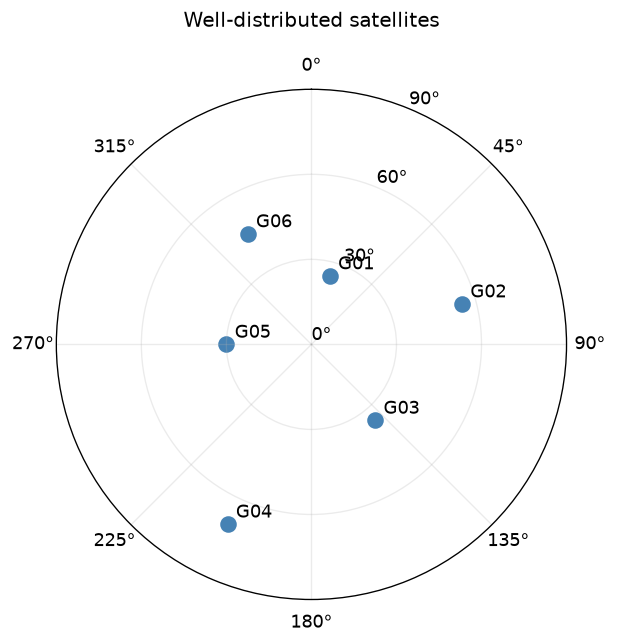

Solver iterations:       3
Pseudorange noise:        3.0 m
3-D position error:       5.36 m
True receiver-clock bias: 100.00 microseconds
Estimated clock bias:     100.01 microseconds


In [8]:
# Simulated receiver near Davis, California
receiver_latitude = 38.5382
receiver_longitude = -121.7617
receiver_height = 30.0
true_position = geodetic_to_ecef(
    receiver_latitude, receiver_longitude, receiver_height
)

# A favorable set of satellites distributed across the sky
azimuths_good = np.array([15, 75, 140, 205, 270, 330])
elevations_good = np.array([25, 55, 35, 70, 30, 45])

satellites_good = satellites_from_sky(
    azimuths_good,
    elevations_good,
    true_position,
    receiver_latitude,
    receiver_longitude,
)

# Generate pseudoranges: geometric range + clock bias + code error
clock_bias_seconds = 100e-6
clock_bias_meters = c * clock_bias_seconds
pseudorange_sigma = 3.0
rng = np.random.default_rng(166)

true_ranges = np.linalg.norm(satellites_good - true_position, axis=1)
pseudoranges = (
    true_ranges
    + clock_bias_meters
    + rng.normal(0, pseudorange_sigma, len(true_ranges))
)

# Start from an approximate position about 1 km from the truth.
initial_position = true_position + np.array([800.0, -600.0, 500.0])
estimated_state, iterations = solve_position(
    satellites_good, pseudoranges, initial_position
)

position_error = np.linalg.norm(estimated_state[:3] - true_position)
estimated_clock_seconds = estimated_state[3] / c

sky_plot(azimuths_good, elevations_good, "Well-distributed satellites")

print(f"Solver iterations:       {iterations}")
print(f"Pseudorange noise:        {pseudorange_sigma:.1f} m")
print(f"3-D position error:       {position_error:.2f} m")
print(f"True receiver-clock bias: {clock_bias_seconds * 1e6:.2f} microseconds")
print(f"Estimated clock bias:     {estimated_clock_seconds * 1e6:.2f} microseconds")

> **Interpret the position solution:**
> 1. Is the receiver-clock range contribution close to your prediction?
> 2. How closely does the solver recover the clock bias?
> 3. Is the three-dimensional position error exactly equal to the 3 m pseudorange noise? Explain why individual range errors combine differently in the position solution.

---

## Part V: Investigate satellite geometry

Measurement precision is not the only control on position precision. Satellites spread broadly across the sky constrain the receiver from several directions. Clustered satellites provide partly redundant geometric information.

### Prediction 3

Before running the comparison, predict which geometry will produce:

- lower PDOP
- smaller position error

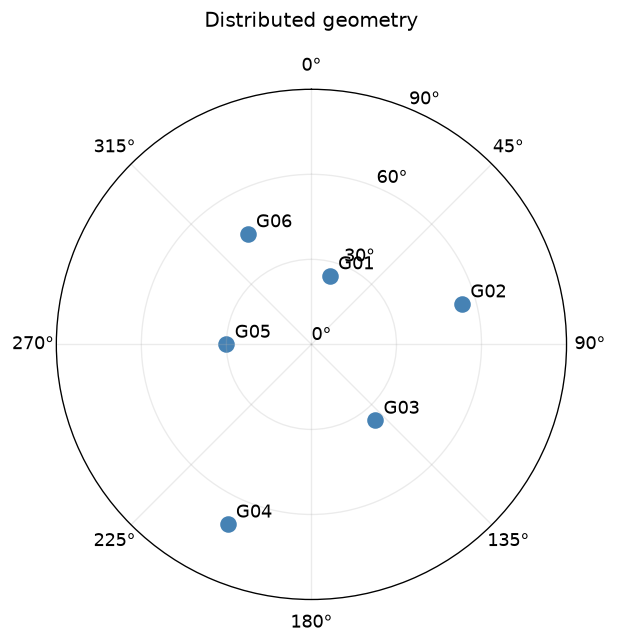

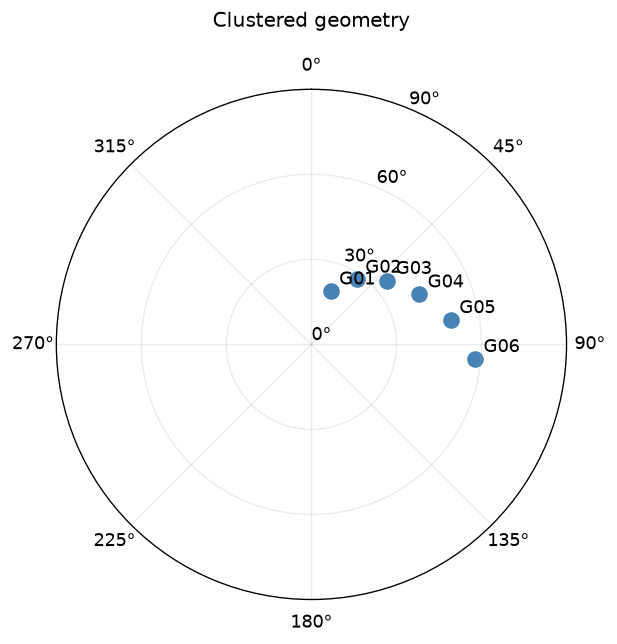

Geometry       Satellites       PDOP    3-D error (m)
------------------------------------------------------
Distributed             6       2.69             3.87
Clustered               6      46.37           101.50


In [9]:
def run_geometry_experiment(name, azimuths, elevations, noise_values):
    satellites = satellites_from_sky(
        azimuths,
        elevations,
        true_position,
        receiver_latitude,
        receiver_longitude,
    )
    ranges = np.linalg.norm(satellites - true_position, axis=1)
    observations = ranges + clock_bias_meters + noise_values[:len(ranges)]
    state, _ = solve_position(satellites, observations, initial_position)
    pdop, gdop = compute_dop(satellites, true_position)
    error = np.linalg.norm(state[:3] - true_position)
    return {
        "name": name,
        "satellites": len(azimuths),
        "pdop": pdop,
        "gdop": gdop,
        "position_error": error,
    }


azimuths_clustered = np.array([20, 35, 50, 65, 80, 95])
elevations_clustered = np.array([20, 28, 35, 42, 50, 58])

# Use the same measurement errors so geometry is the principal difference.
shared_noise = np.random.default_rng(42).normal(0, 3.0, 6)

results = [
    run_geometry_experiment(
        "Distributed", azimuths_good, elevations_good, shared_noise
    ),
    run_geometry_experiment(
        "Clustered", azimuths_clustered, elevations_clustered, shared_noise
    ),
]

sky_plot(azimuths_good, elevations_good, "Distributed geometry")
sky_plot(azimuths_clustered, elevations_clustered, "Clustered geometry")

print(f"{'Geometry':<14} {'Satellites':>10} {'PDOP':>10} {'3-D error (m)':>16}")
print("-" * 54)
for result in results:
    print(
        f"{result['name']:<14} "
        f"{result['satellites']:>10d} "
        f"{result['pdop']:>10.2f} "
        f"{result['position_error']:>16.2f}"
    )

> **Record and interpret your results:**
> | Geometry | Number of satellites | PDOP | 3-D position error |
> | --- | ---: | ---: | ---: |
> | Distributed |  |  |  |
> | Clustered |  |  |  |
> 1. Did the results agree with your prediction?
> 2. Both configurations used six satellites and the same pseudorange errors. Why did their position errors differ?

### Design your own geometry

Modify the azimuths and elevations below. Try one of the following:

- use exactly four satellites
- place all satellites at low elevation
- add a satellite nearly overhead
- design the lowest-PDOP configuration you can

All azimuth and elevation arrays must have the same length, with at least four satellites.

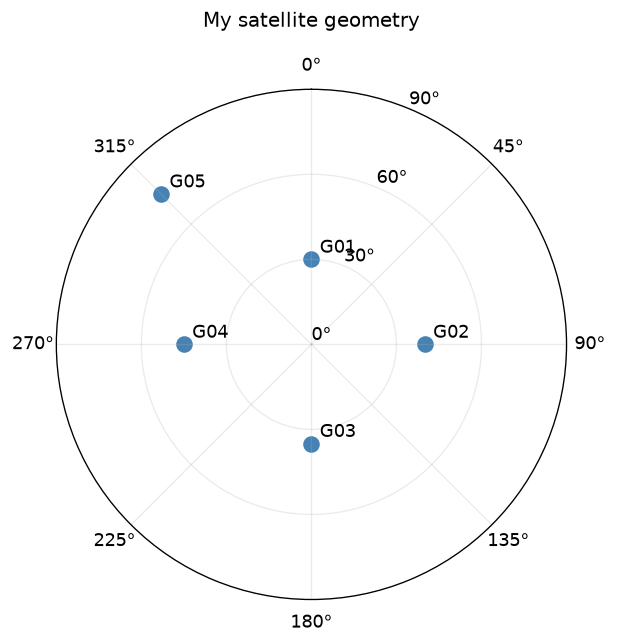

Number of satellites: 5
PDOP:                 3.18
3-D position error:   19.44 m


In [10]:
# Modify these values.
my_azimuths = np.array([0, 90, 180, 270, 315])
my_elevations = np.array([30, 40, 35, 45, 75])

if len(my_azimuths) != len(my_elevations):
    raise ValueError("Azimuth and elevation arrays must have the same length.")
if len(my_azimuths) < 4:
    raise ValueError("At least four satellites are required.")

my_noise = np.random.default_rng(42).normal(0, 3.0, len(my_azimuths))
my_result = run_geometry_experiment(
    "My geometry", my_azimuths, my_elevations, my_noise
)

sky_plot(my_azimuths, my_elevations, "My satellite geometry")
print(f"Number of satellites: {my_result['satellites']}")
print(f"PDOP:                 {my_result['pdop']:.2f}")
print(f"3-D position error:   {my_result['position_error']:.2f} m")

> **Interpret your experiment:**
> 1. Describe the geometry you tested.
> 2. What PDOP and position error did it produce?
> 3. What change would you make to improve it?

---

## Part VI: Optional extension: Why code does not identify one carrier cycle

Suppose the code range is uncertain by $\pm3$ m. The L1 carrier wavelength is only about 19 cm, so many carrier cycles are consistent with the code estimate.

In [11]:
code_uncertainty = 3.0
full_uncertainty_width = 2 * code_uncertainty
possible_cycles = full_uncertainty_width / lambda_L1

print(f"L1 wavelength:                    {lambda_L1:.3f} m")
print(f"Width of the ±3 m code interval:  {full_uncertainty_width:.1f} m")
print(f"Carrier cycles in that interval:  {possible_cycles:.1f}")

L1 wavelength:                    0.190 m
Width of the ±3 m code interval:  6.0 m
Carrier cycles in that interval:  31.5


Carrier phase measures the fractional position within a cycle very precisely, but the receiver initially does not know the total number of complete cycles:

$$
\rho=\lambda(N+\phi).
$$

Long, continuous observations from many satellites constrain the station position, atmospheric delays, clocks, and the ambiguity associated with each satellite.

---
## Synthesis

> **Answer each question in one or two sentences:**
> 1. How does a receiver use a PRN code to identify a satellite and measure its signal-arrival time?
> 2. Why must receiver-clock bias be estimated along with the three position coordinates?
> 3. Why can receivers with equally precise pseudorange measurements obtain different position uncertainties?
> 4. Why is code-based positioning insufficient for measuring tectonic deformation?
> 5. What additional information does carrier phase provide, and what new ambiguity does it introduce?

---

## Summary

- PRN codes and navigation data are encoded as phase reversals of a carrier wave.
- Correlation with known PRN codes identifies a satellite and measures code timing.
- Code timing produces a pseudorange rather than a pure geometric distance.
- At least four satellites are required to solve for three position coordinates and receiver-clock bias.
- Satellite geometry controls how measurement errors propagate into position errors.
- Carrier phase provides the sensitivity needed for geodetic applications but introduces an integer ambiguity.

This notebook was adapted for EPS 166 from material developed for the CRESCENT Technical Short Course on Strain Accumulation and Release from GNSS by Brendan Crowell.